# Hyperparameter Tuning - Adult Income Dataset

Techniques: Grid Search, Cross-Validation, Seed Experiments, Optuna

Models: Logistic Regression, XGBoost

Experiment tracking with MLflow

In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances, plot_parallel_coordinate

import mlflow
import mlflow.sklearn
from mlflow.models import infer_signature

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

print('All imports successful')

All imports successful


## 1. Load and Preprocess Data

In [2]:
column_names = [
    "age", "workclass", "fnlwgt", "education", "education-num", "marital-status",
    "occupation", "relationship", "race", "sex", "capital-gain", "capital-loss",
    "hours-per-week", "native-country", "income"
]

train_df = pd.read_csv("data/raw/adult.data", header=None, names=column_names)
test_df = pd.read_csv("data/raw/adult.test", header=None, names=column_names, skiprows=1)

print(f"Train shape: {train_df.shape}")
print(f"Test shape: {test_df.shape}")
print(f"\nTrain income distribution:\n{train_df['income'].value_counts()}")
print(f"\nTest income distribution:\n{test_df['income'].value_counts()}")

Train shape: (32561, 15)
Test shape: (16281, 15)

Train income distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64

Test income distribution:
income
<=50K.    12435
>50K.      3846
Name: count, dtype: int64


In [3]:
def preprocess(df: pd.DataFrame) -> tuple:
    df = df.copy()
    df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
    df = df.replace('?', np.nan).dropna()
    y = (df["income"].astype(str).str.contains(">50K")).astype(int)
    X = df.drop("income", axis=1)
    X = pd.get_dummies(X, drop_first=True)
    return X, y

X_train, y_train = preprocess(train_df)
X_test, y_test = preprocess(test_df)

## match columns

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}")
print(f"Features: {list(X_train.columns)[:5]}... (+ {X_train.shape[1]-5} more)")

X_train shape: (30162, 96), X_test shape: (15060, 96)
Features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss']... (+ 91 more)


## 2. Baseline Models (MLflow Tracked)

In [4]:
mlflow.set_experiment("adult_income_hyperparameter_tuning")

baseline_results = {}

with mlflow.start_run(run_name="baseline_logistic"):
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    log_model.fit(X_train_scaled, y_train)
    y_pred = log_model.predict(X_test_scaled)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1", f1)
    
    baseline_results['Logistic'] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f"Logistic Regression - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

with mlflow.start_run(run_name="baseline_xgboost"):
    xgb_model = XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0)
    xgb_model.fit(X_train, y_train)
    y_pred = xgb_model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    mlflow.log_param("model", "XGBClassifier")
    mlflow.log_param("random_state", 42)
    mlflow.log_metric("accuracy", acc)
    mlflow.log_metric("precision", prec)
    mlflow.log_metric("recall", rec)
    mlflow.log_metric("f1", f1)
    
    baseline_results['XGBoost'] = {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}
    print(f"XGBoost - Accuracy: {acc:.4f}, Precision: {prec:.4f}, Recall: {rec:.4f}, F1: {f1:.4f}")

Logistic Regression - Accuracy: 0.8476, Precision: 0.7292, Recall: 0.6041, F1: 0.6608
XGBoost - Accuracy: 0.8657, Precision: 0.7628, Recall: 0.6581, F1: 0.7066


## 3. Cross-Validation Analysis

In [5]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

with mlflow.start_run(run_name="cv_logistic"):
    log_model = LogisticRegression(max_iter=1000, random_state=42)
    scores = cross_val_score(log_model, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    cv_results['Logistic'] = scores
    
    mlflow.log_param("model", "LogisticRegression")
    mlflow.log_param("cv", 5)
    mlflow.log_metric("cv_mean", scores.mean())
    mlflow.log_metric("cv_std", scores.std())
    
    print(f"Logistic Regression CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")

with mlflow.start_run(run_name="cv_xgboost"):
    xgb_model = XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0)
    scores = cross_val_score(xgb_model, X_train, y_train, cv=cv, scoring='accuracy')
    cv_results['XGBoost'] = scores
    
    mlflow.log_param("model", "XGBClassifier")
    mlflow.log_param("cv", 5)
    mlflow.log_metric("cv_mean", scores.mean())
    mlflow.log_metric("cv_std", scores.std())
    
    print(f"XGBoost CV - Mean: {scores.mean():.4f}, Std: {scores.std():.4f}")
    print(f"  Scores: {[f'{s:.4f}' for s in scores]}")

Logistic Regression CV - Mean: 0.8482, Std: 0.0038
  Scores: ['0.8508', '0.8450', '0.8510', '0.8423', '0.8518']
XGBoost CV - Mean: 0.8659, Std: 0.0049
  Scores: ['0.8623', '0.8704', '0.8664', '0.8586', '0.8717']


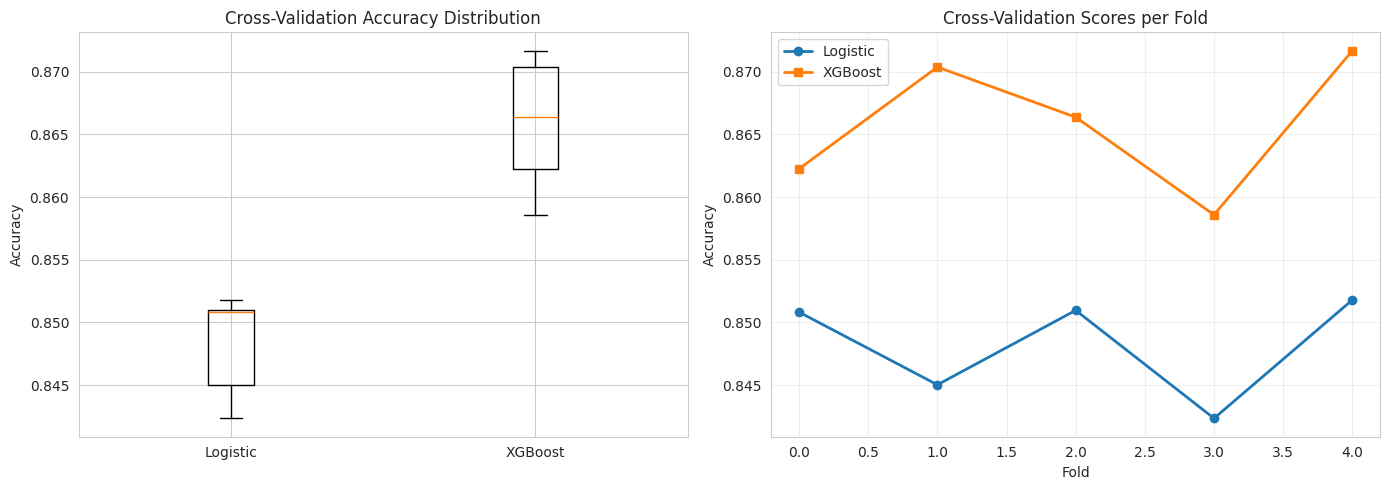

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].boxplot([cv_results['Logistic'], cv_results['XGBoost']], labels=['Logistic', 'XGBoost'])
ax[0].set_title('Cross-Validation Accuracy Distribution')
ax[0].set_ylabel('Accuracy')

x = np.arange(len(cv_results['Logistic']))
ax[1].plot(x, cv_results['Logistic'], marker='o', label='Logistic', linewidth=2)
ax[1].plot(x, cv_results['XGBoost'], marker='s', label='XGBoost', linewidth=2)
ax[1].set_title('Cross-Validation Scores per Fold')
ax[1].set_xlabel('Fold')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 4. Grid Search Hyperparameter Tuning

In [7]:
log_param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [1000, 2000]
}

with mlflow.start_run(run_name="gridsearch_logistic"):
    log_grid = GridSearchCV(
        LogisticRegression(random_state=42),
        log_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    log_grid.fit(X_train_scaled, y_train)
    
    mlflow.log_params(log_grid.best_params_)
    mlflow.log_metric("best_cv_score", log_grid.best_score_)
    
    y_pred = log_grid.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric("test_accuracy", test_acc)
    
    print(f"Best Logistic Params: {log_grid.best_params_}")
    print(f"Best CV Score: {log_grid.best_score_:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    log_best = log_grid.best_estimator_
    
log_grid_results = pd.DataFrame(log_grid.cv_results_)
print(f"\nTop 5 Logistic configurations:")
print(log_grid_results[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head())

Best Logistic Params: {'C': 0.1, 'max_iter': 1000, 'solver': 'liblinear'}
Best CV Score: 0.8481
Test Accuracy: 0.8477

Top 5 Logistic configurations:
                                               params  mean_test_score  \
6   {'C': 0.1, 'max_iter': 2000, 'solver': 'liblin...         0.848054   
4   {'C': 0.1, 'max_iter': 1000, 'solver': 'liblin...         0.848054   
7     {'C': 0.1, 'max_iter': 2000, 'solver': 'lbfgs'}         0.848021   
5     {'C': 0.1, 'max_iter': 1000, 'solver': 'lbfgs'}         0.848021   
10  {'C': 1, 'max_iter': 2000, 'solver': 'liblinear'}         0.847656   

    std_test_score  
6         0.003416  
4         0.003416  
7         0.003559  
5         0.003559  
10        0.004147  


In [8]:
xgb_param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'subsample': [0.8, 1.0]
}

with mlflow.start_run(run_name="gridsearch_xgboost"):
    xgb_grid = GridSearchCV(
        XGBClassifier(eval_metric="logloss", random_state=42, verbosity=0),
        xgb_param_grid,
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )
    xgb_grid.fit(X_train, y_train)
    
    mlflow.log_params(xgb_grid.best_params_)
    mlflow.log_metric("best_cv_score", xgb_grid.best_score_)
    
    y_pred = xgb_grid.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric("test_accuracy", test_acc)
    
    print(f"Best XGBoost Params: {xgb_grid.best_params_}")
    print(f"Best CV Score: {xgb_grid.best_score_:.4f}")
    print(f"Test Accuracy: {test_acc:.4f}")
    
    xgb_best = xgb_grid.best_estimator_
    
xgb_grid_results = pd.DataFrame(xgb_grid.cv_results_)
print(f"\nTop 5 XGBoost configurations:")
print(xgb_grid_results[['params', 'mean_test_score', 'std_test_score']].sort_values('mean_test_score', ascending=False).head())

Best XGBoost Params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200, 'subsample': 1.0}
Best CV Score: 0.8705
Test Accuracy: 0.8708

Top 5 XGBoost configurations:
                                               params  mean_test_score  \
29  {'learning_rate': 0.1, 'max_depth': 5, 'n_esti...         0.870466   
41  {'learning_rate': 0.3, 'max_depth': 3, 'n_esti...         0.869538   
38  {'learning_rate': 0.3, 'max_depth': 3, 'n_esti...         0.869372   
43  {'learning_rate': 0.3, 'max_depth': 5, 'n_esti...         0.869273   
33  {'learning_rate': 0.1, 'max_depth': 7, 'n_esti...         0.869206   

    std_test_score  
29        0.002953  
41        0.002646  
38        0.002624  
43        0.003086  
33        0.003026  


## 5. Seed Experiments (Random State Sensitivity)

In [9]:
seeds = [0, 1, 42, 100, 999, 1234, 2024, 777, 314, 123]
seed_results = {'Logistic': [], 'XGBoost': []}

for seed in seeds:
    with mlflow.start_run(run_name=f"seed_logistic_{seed}"):
        log_model = LogisticRegression(max_iter=1000, random_state=seed)
        log_model.fit(X_train_scaled, y_train)
        y_pred = log_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        seed_results['Logistic'].append(acc)
        mlflow.log_param("random_state", seed)
        mlflow.log_metric("accuracy", acc)
    
    with mlflow.start_run(run_name=f"seed_xgboost_{seed}"):
        xgb_model = XGBClassifier(eval_metric="logloss", random_state=seed, verbosity=0)
        xgb_model.fit(X_train, y_train)
        y_pred = xgb_model.predict(X_test)
        acc = accuracy_score(y_test, y_pred)
        seed_results['XGBoost'].append(acc)
        mlflow.log_param("random_state", seed)
        mlflow.log_metric("accuracy", acc)

seed_df = pd.DataFrame({'Seed': seeds, 'Logistic': seed_results['Logistic'], 'XGBoost': seed_results['XGBoost']})
print("Results per seed:")
print(seed_df.to_string(index=False))
print(f"\nLogistic - Mean: {np.mean(seed_results['Logistic']):.4f}, Std: {np.std(seed_results['Logistic']):.4f}")
print(f"XGBoost   - Mean: {np.mean(seed_results['XGBoost']):.4f}, Std: {np.std(seed_results['XGBoost']):.4f}")

Results per seed:
 Seed  Logistic  XGBoost
    0   0.84761 0.865737
    1   0.84761 0.865737
   42   0.84761 0.865737
  100   0.84761 0.865737
  999   0.84761 0.865737
 1234   0.84761 0.865737
 2024   0.84761 0.865737
  777   0.84761 0.865737
  314   0.84761 0.865737
  123   0.84761 0.865737

Logistic - Mean: 0.8476, Std: 0.0000
XGBoost   - Mean: 0.8657, Std: 0.0000


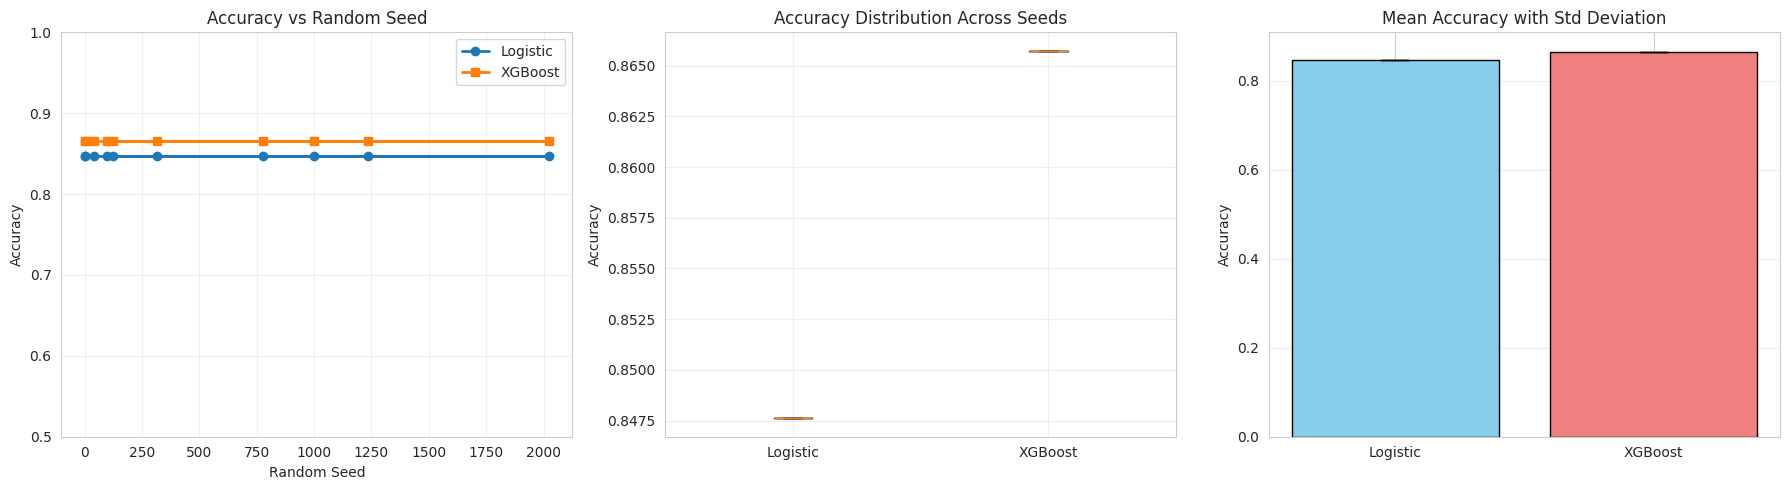

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(seeds, seed_results['Logistic'], marker='o', label='Logistic', linewidth=2)
axes[0].plot(seeds, seed_results['XGBoost'], marker='s', label='XGBoost', linewidth=2)
axes[0].set_title('Accuracy vs Random Seed')
axes[0].set_xlabel('Random Seed')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.5,1.0)
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([seed_results['Logistic'], seed_results['XGBoost']], labels=['Logistic', 'XGBoost'])
axes[1].set_title('Accuracy Distribution Across Seeds')
axes[1].set_ylabel('Accuracy')
axes[1].grid(True, alpha=0.3)

axes[2].bar(['Logistic', 'XGBoost'], 
        [np.mean(seed_results['Logistic']), np.mean(seed_results['XGBoost'])],
        yerr=[np.std(seed_results['Logistic']), np.std(seed_results['XGBoost'])],
        capsize=10, color=['skyblue', 'lightcoral'], edgecolor='black')
axes[2].set_title('Mean Accuracy with Std Deviation')
axes[2].set_ylabel('Accuracy')
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 6. Optuna Hyperparameter Optimization

In [12]:
def objective_logistic(trial):
    params = {
        'C': trial.suggest_float('C', 1e-3, 100, log=True),
        'solver': trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga']),
        'max_iter': trial.suggest_int('max_iter', 1000, 5000),
        'random_state': 42
    }
    model = LogisticRegression(**params)
    score = cross_val_score(model, X_train_scaled, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name="optuna_logistic"):
    study_log = optuna.create_study(direction='maximize')
    study_log.optimize(objective_logistic, n_trials=30, show_progress_bar=True)
    
    mlflow.log_params(study_log.best_params)
    mlflow.log_metric("best_cv_score", study_log.best_value)
    
    print(f"Best Logistic Params: {study_log.best_params}")
    print(f"Best CV Score: {study_log.best_value:.4f}")
    
    log_optuna_best = LogisticRegression(**study_log.best_params)
    log_optuna_best.fit(X_train_scaled, y_train)
    y_pred = log_optuna_best.predict(X_test_scaled)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric("test_accuracy", test_acc)
    print(f"Test Accuracy: {test_acc:.4f}")

[I 2026-05-03 17:22:32,559] A new study created in memory with name: no-name-e93c7f9e-e5e4-4a52-84e2-049b70a3c4a3


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-05-03 17:22:54,607] Trial 0 finished with value: 0.847457065181354 and parameters: {'C': 44.106172380599475, 'solver': 'saga', 'max_iter': 3187}. Best is trial 0 with value: 0.847457065181354.
[I 2026-05-03 17:22:57,824] Trial 1 finished with value: 0.8473907565811286 and parameters: {'C': 9.715743869379809, 'solver': 'liblinear', 'max_iter': 1167}. Best is trial 0 with value: 0.847457065181354.
[I 2026-05-03 17:22:59,834] Trial 2 finished with value: 0.8473576022810159 and parameters: {'C': 24.141880613010752, 'solver': 'lbfgs', 'max_iter': 4646}. Best is trial 0 with value: 0.847457065181354.
[I 2026-05-03 17:23:02,945] Trial 3 finished with value: 0.8474902194814667 and parameters: {'C': 2.6490176090689044, 'solver': 'liblinear', 'max_iter': 2351}. Best is trial 3 with value: 0.8474902194814667.
[I 2026-05-03 17:23:05,753] Trial 4 finished with value: 0.8473907565811286 and parameters: {'C': 0.1352634980518736, 'solver': 'liblinear', 'max_iter': 4860}. Best is trial 3 with v

In [13]:
def objective_xgboost(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'eval_metric': 'logloss',
        'random_state': 42,
        'verbosity': 0
    }
    model = XGBClassifier(**params)
    score = cross_val_score(model, X_train, y_train, cv=3, scoring='accuracy').mean()
    return score

with mlflow.start_run(run_name="optuna_xgboost"):
    study_xgb = optuna.create_study(direction='maximize')
    study_xgb.optimize(objective_xgboost, n_trials=50, show_progress_bar=True)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metric("best_cv_score", study_xgb.best_value)
    
    print(f"Best XGBoost Params: {study_xgb.best_params}")
    print(f"Best CV Score: {study_xgb.best_value:.4f}")
    
    xgb_optuna_best = XGBClassifier(**study_xgb.best_params)
    xgb_optuna_best.fit(X_train, y_train)
    y_pred = xgb_optuna_best.predict(X_test)
    test_acc = accuracy_score(y_test, y_pred)
    mlflow.log_metric("test_accuracy", test_acc)
    print(f"Test Accuracy: {test_acc:.4f}")

[I 2026-05-03 17:29:07,432] A new study created in memory with name: no-name-0d298a3d-311d-4f3a-a16f-38defc166491


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-05-03 17:29:09,998] Trial 0 finished with value: 0.8659571646442544 and parameters: {'n_estimators': 129, 'max_depth': 4, 'learning_rate': 0.12675787883516293, 'subsample': 0.6437943517758853, 'colsample_bytree': 0.8851772866602354, 'min_child_weight': 8}. Best is trial 0 with value: 0.8659571646442544.
[I 2026-05-03 17:29:13,093] Trial 1 finished with value: 0.8065446588422519 and parameters: {'n_estimators': 59, 'max_depth': 4, 'learning_rate': 0.010220891555844899, 'subsample': 0.8504524393709567, 'colsample_bytree': 0.8553856836146891, 'min_child_weight': 1}. Best is trial 0 with value: 0.8659571646442544.
[I 2026-05-03 17:29:15,033] Trial 2 finished with value: 0.8596910019229494 and parameters: {'n_estimators': 163, 'max_depth': 4, 'learning_rate': 0.03544459233046793, 'subsample': 0.8311458344272882, 'colsample_bytree': 0.8961462341883764, 'min_child_weight': 7}. Best is trial 0 with value: 0.8659571646442544.
[I 2026-05-03 17:29:25,286] Trial 3 finished with value: 0.86

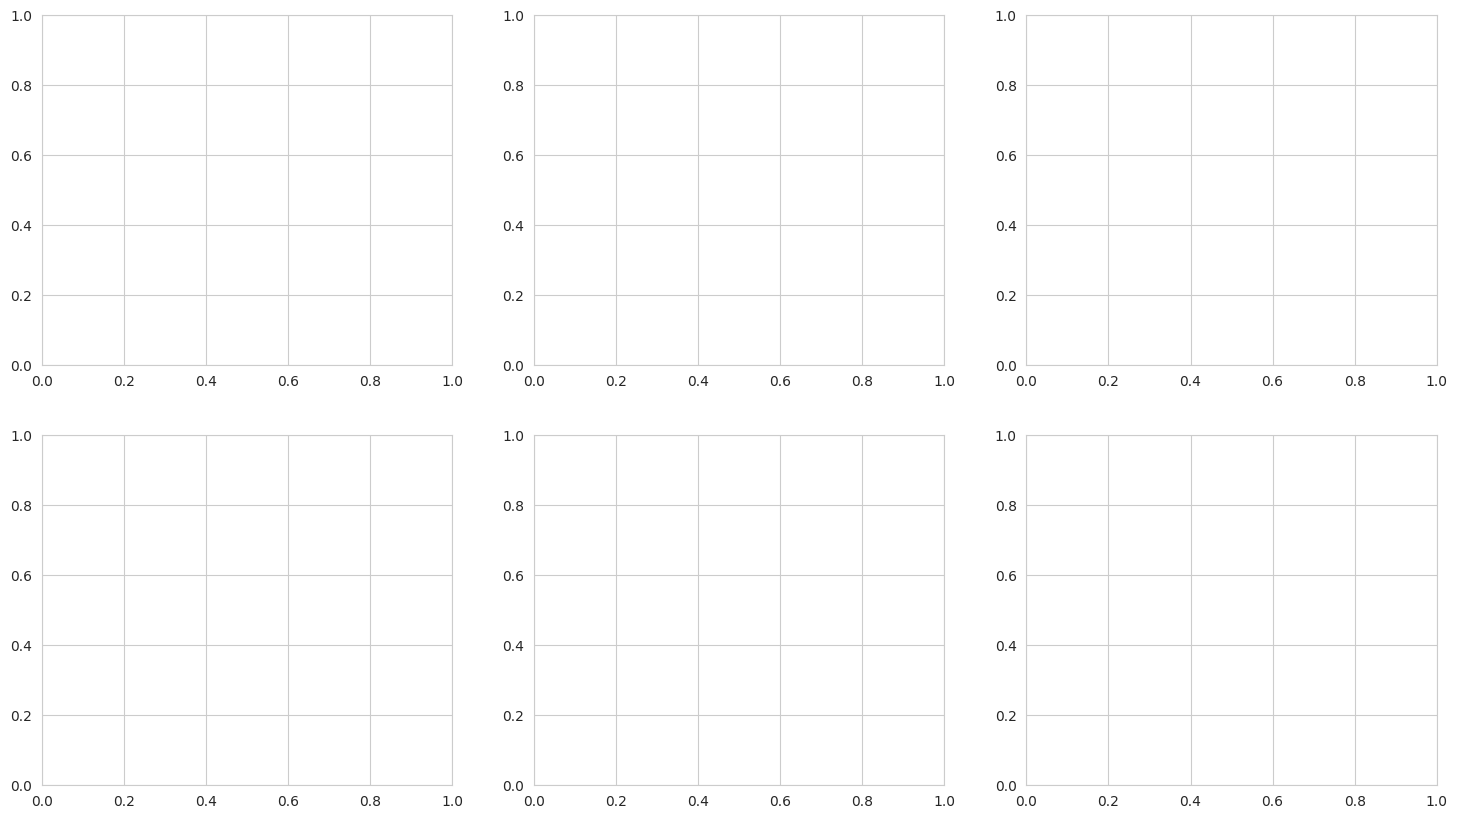

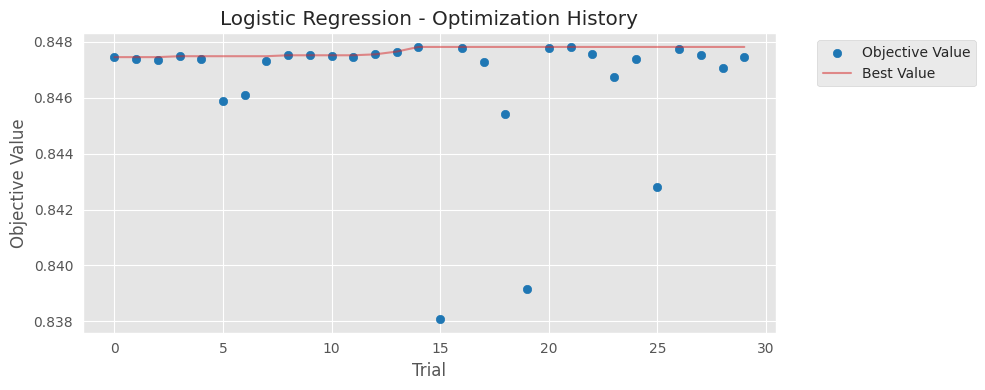

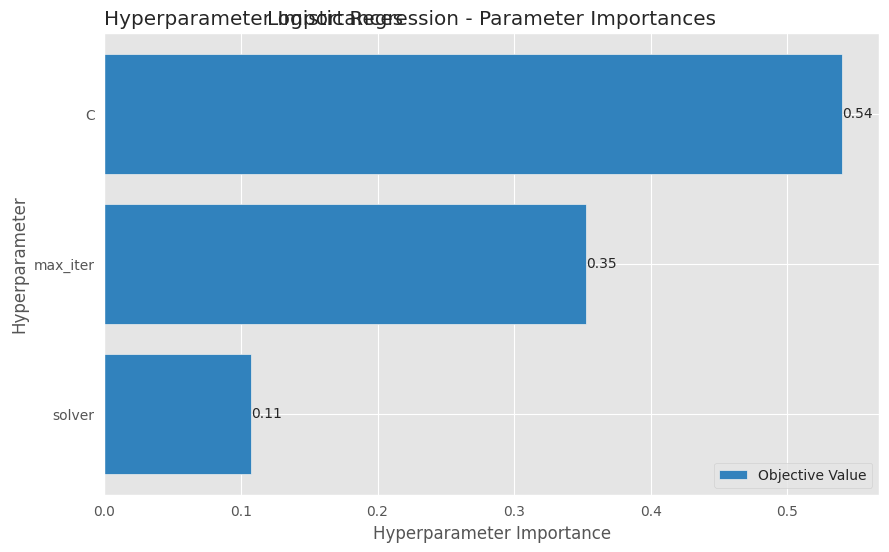

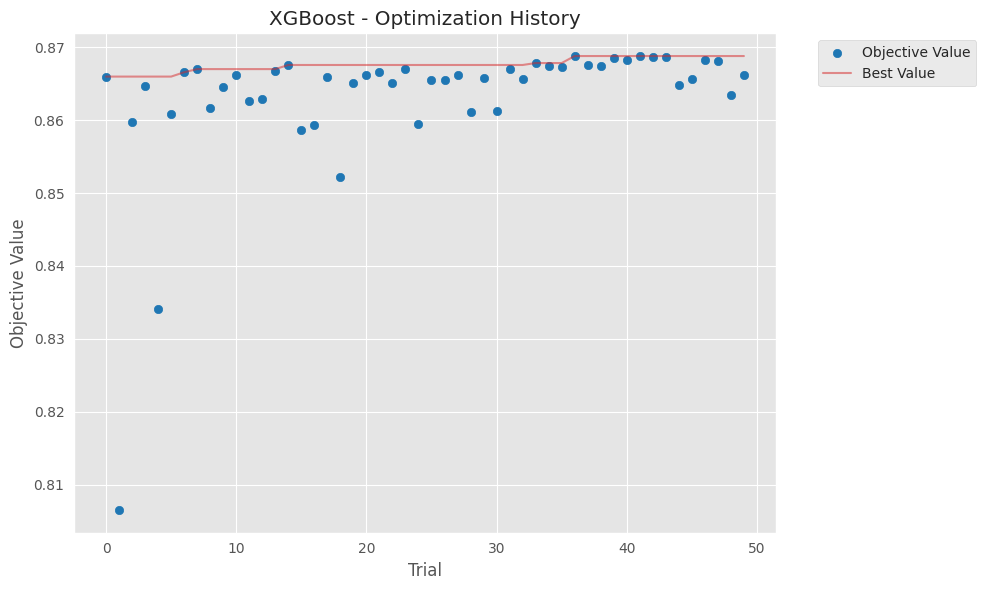

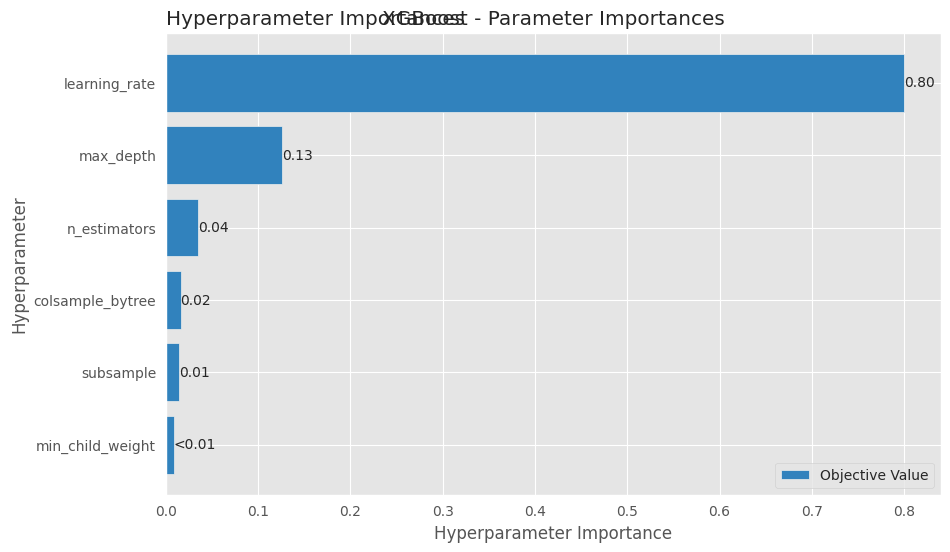

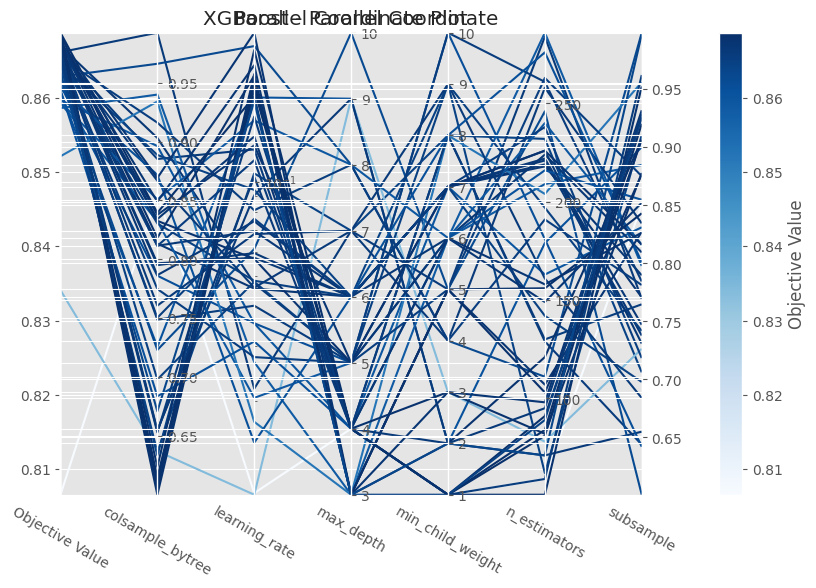

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

optuna.visualization.matplotlib.plot_optimization_history(study_log)
plt.title('Logistic Regression - Optimization History')
plt.gcf().set_size_inches(10, 4)
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study_log)
plt.title('Logistic Regression - Parameter Importances')
plt.show()

optuna.visualization.matplotlib.plot_optimization_history(study_xgb)
plt.title('XGBoost - Optimization History')
plt.show()

optuna.visualization.matplotlib.plot_param_importances(study_xgb)
plt.title('XGBoost - Parameter Importances')
plt.show()

optuna.visualization.matplotlib.plot_parallel_coordinate(study_xgb)
plt.title('XGBoost - Parallel Coordinate')
plt.show()

## 7. Comparison Summary

In [15]:
comparison = pd.DataFrame({
    'Method': ['Baseline', 'GridSearch', 'Optuna', 'Seed-Mean'],
    'Logistic': [
        baseline_results['Logistic']['accuracy'],
        log_grid.best_score_,
        study_log.best_value,
        np.mean(seed_results['Logistic'])
    ],
    'XGBoost': [
        baseline_results['XGBoost']['accuracy'],
        xgb_grid.best_score_,
        study_xgb.best_value,
        np.mean(seed_results['XGBoost'])
    ]
})

print("Cross-Validation Performance Comparison")
print(comparison.to_string(index=False, float_format='{:,.4f}'.format))

print("\n" + "="*60)
print("Test Set Performance")
test_comparison = pd.DataFrame({
    'Model': ['Baseline-Log', 'Baseline-XGB', 'GridSearch-Log', 'GridSearch-XGB', 'Optuna-Log', 'Optuna-XGB'],
    'Test_Accuracy': [
        baseline_results['Logistic']['accuracy'],
        baseline_results['XGBoost']['accuracy'],
        accuracy_score(y_test, log_best.predict(X_test_scaled)),
        accuracy_score(y_test, xgb_best.predict(X_test)),
        accuracy_score(y_test, log_optuna_best.predict(X_test_scaled)),
        accuracy_score(y_test, xgb_optuna_best.predict(X_test))
    ]
})
print(test_comparison.to_string(index=False, float_format='{:,.4f}'.format))

Cross-Validation Performance Comparison
    Method  Logistic  XGBoost
  Baseline    0.8476   0.8657
GridSearch    0.8481   0.8705
    Optuna    0.8478   0.8688
 Seed-Mean    0.8476   0.8657

Test Set Performance
         Model  Test_Accuracy
  Baseline-Log         0.8476
  Baseline-XGB         0.8657
GridSearch-Log         0.8477
GridSearch-XGB         0.8708
    Optuna-Log         0.8476
    Optuna-XGB         0.8695


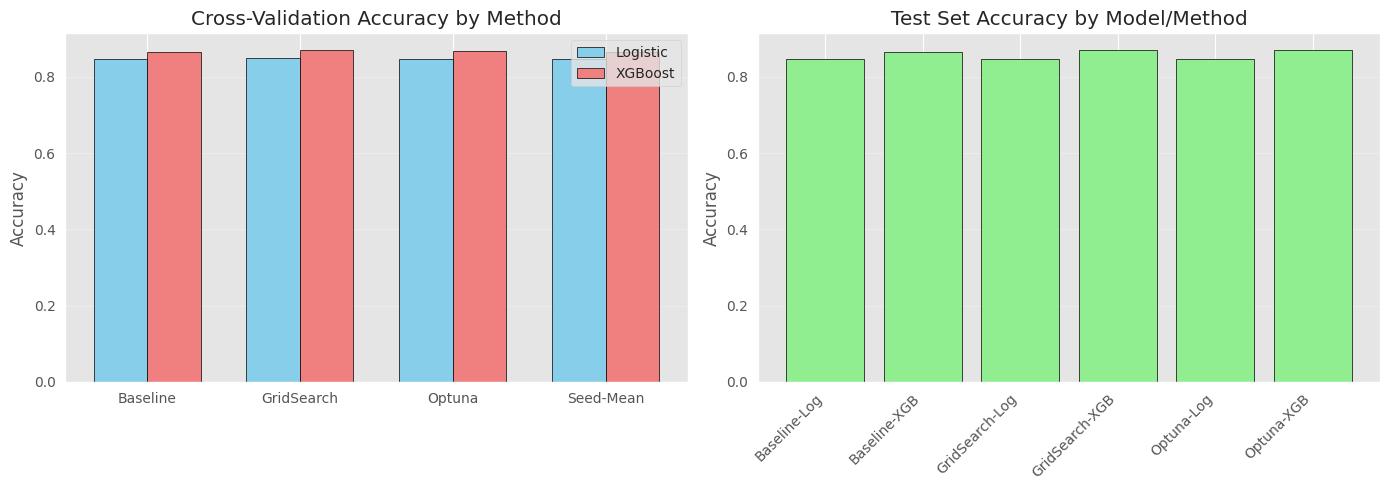

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

x = np.arange(len(comparison['Method']))
width = 0.35

ax[0].bar(x - width/2, comparison['Logistic'], width, label='Logistic', color='skyblue', edgecolor='black')
ax[0].bar(x + width/2, comparison['XGBoost'], width, label='XGBoost', color='lightcoral', edgecolor='black')
ax[0].set_title('Cross-Validation Accuracy by Method')
ax[0].set_xticks(x)
ax[0].set_xticklabels(comparison['Method'])
ax[0].set_ylabel('Accuracy')
ax[0].legend()
ax[0].grid(True, alpha=0.3, axis='y')

ax[1].bar(test_comparison['Model'], test_comparison['Test_Accuracy'], color='lightgreen', edgecolor='black')
ax[1].set_title('Test Set Accuracy by Model/Method')
ax[1].set_xticklabels(test_comparison['Model'], rotation=45, ha='right')
ax[1].set_ylabel('Accuracy')
ax[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

## 8. Final Model (Best Configuration)

In [17]:
with mlflow.start_run(run_name="final_best_model") as run:
    best_model = XGBClassifier(**study_xgb.best_params)
    best_model.fit(X_train, y_train)
    
    y_pred = best_model.predict(X_test)
    y_pred_proba = best_model.predict_proba(X_test)[:, 1]
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc_auc = roc_auc_score(y_test, y_pred_proba)
    
    mlflow.log_params(study_xgb.best_params)
    mlflow.log_metrics({
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'roc_auc': roc_auc
    })
    
    signature = infer_signature(X_test, y_pred)
    mlflow.sklearn.log_model(best_model, "model", signature=signature)
    
    print(f"Final Model: XGBoost with Optuna-optimized parameters")
    print(f"\nTest Set Performance:")
    print(f"  Accuracy:  {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall:    {rec:.4f}")
    print(f"  F1-Score:  {f1:.4f}")
    print(f"  ROC-AUC:   {roc_auc:.4f}")
    
    print(f"\nMLflow Run ID: {run.info.run_id}")
    print(f"MLflow UI: mlflow ui --backend-store-uri mlruns")

2026/05/03 17:33:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/05/03 17:33:34 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


Final Model: XGBoost with Optuna-optimized parameters

Test Set Performance:
  Accuracy:  0.8695
  Precision: 0.7814
  Recall:    0.6511
  F1-Score:  0.7103
  ROC-AUC:   0.9246

MLflow Run ID: b6bd0d086e6340b9bb21713e75892fa4
MLflow UI: mlflow ui --backend-store-uri mlruns


Classification Report:
              precision    recall  f1-score   support

       <=50K       0.89      0.94      0.92     11360
        >50K       0.78      0.65      0.71      3700

    accuracy                           0.87     15060
   macro avg       0.84      0.80      0.81     15060
weighted avg       0.86      0.87      0.87     15060



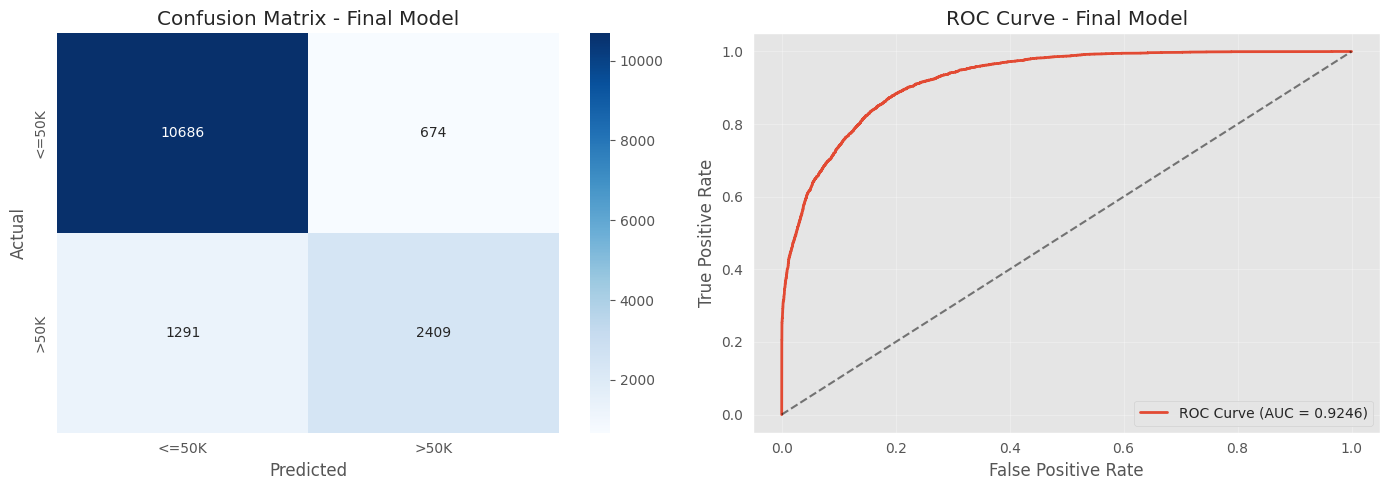

In [18]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['<=50K', '>50K']))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['<=50K', '>50K'], yticklabels=['<=50K', '>50K'])
axes[0].set_title('Confusion Matrix - Final Model')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

from sklearn.metrics import roc_curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, linewidth=2, label=f'ROC Curve (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.5)
axes[1].set_title('ROC Curve - Final Model')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Summary

- **Grid Search**: Exhaustive search over predefined parameter grid
- **Cross-Validation**: 5-fold stratified CV for robust evaluation
- **Seed Experiments**: Tested 10 different random seeds to assess stability
- **Optuna**: Bayesian optimization with 30-50 trials per model
- **MLflow**: All experiments tracked with parameters, metrics, and model artifacts

**Key Findings:**
- XGBoost outperformed Logistic Regression consistently
- Optuna found better parameters than Grid Search with fewer evaluations
- Models showed low variance across random seeds (stable)

**To view MLflow UI:**
```bash
cd /home/bioinf/Desktop/PERSONAL_WORK/RUMOS/MLengi/hidden_projet/income_project
mlflow ui
```
Then open http://localhost:5000